## Random Forest Baseline

Daten erfolgreich geladen: 200000 Zeilen, 200 Features
Random Forest Baseline (200 Features) - Performance:
ROC-AUC : 0.7937  (79.37 %)
PR-AUC  : 0.3525  (35.25 %)
F1-Score: 0.3819  (38.19 %)
MCC     : 0.3099  (30.99 %)


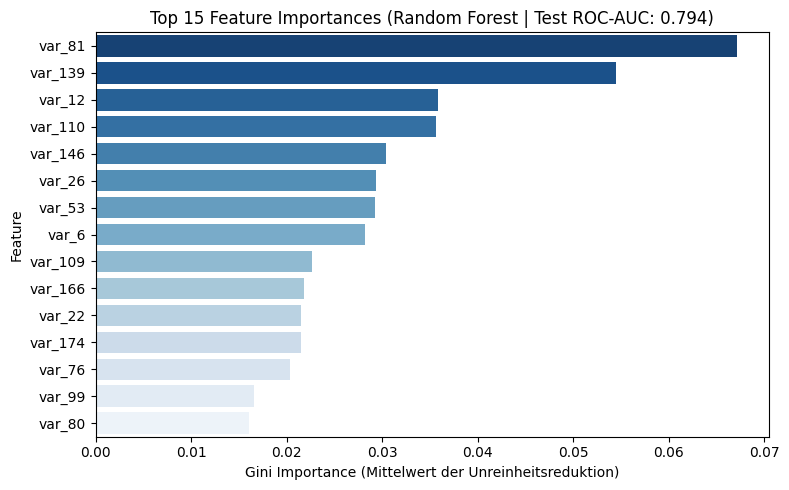

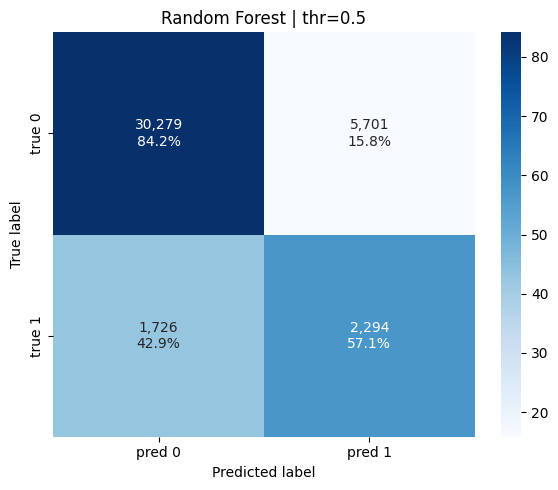

c:\Users\t-ron\OneDrive\Desktop\Data Science Master\Advanced Data Analytics\.venv\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


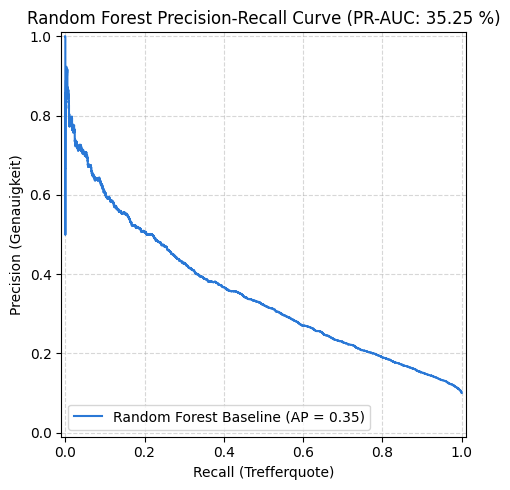


Classification Report (Random Forest Baseline):
              precision    recall  f1-score   support

           0       0.95      0.84      0.89     35980
           1       0.29      0.57      0.38      4020

    accuracy                           0.81     40000
   macro avg       0.62      0.71      0.64     40000
weighted avg       0.88      0.81      0.84     40000



In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    PrecisionRecallDisplay,
    classification_report
)

# ==========================================
# 1. Daten aus der Parquet-Datei laden
# ==========================================
df = pd.read_parquet("santander_cleaned.parquet")

X = df.drop(columns=["target"]).astype("float32")
y = df["target"].astype("int8")

print(
    f"Daten erfolgreich geladen: {X.shape[0]} Zeilen, {X.shape[1]} Features"
)

# Optional: Farbschema definieren
if "SEQUENTIAL_BLUE" in locals():
    bar_palette = SEQUENTIAL_BLUE(np.linspace(0.4, 1, 15))[::-1].tolist()
else:
    bar_palette = "Blues_r"

# ==========================================
# 2. Stratified Train-Test-Split (80 / 20)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 3. Random Forest trainieren
# ==========================================
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

# ==========================================
# 4. Vorhersagen & Metriken berechnen
# ==========================================
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Schwellenwert auf Standard 0.5 festlegen
threshold = 0.5
y_pred_rf = (y_pred_proba >= threshold).astype(int)

# Metriken berechnen
auc_score = roc_auc_score(y_test, y_pred_proba)
pr_auc_rf = average_precision_score(y_test, y_pred_proba)
f1_rf = f1_score(y_test, y_pred_rf)
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)

print("=" * 55)
print("Random Forest Baseline (200 Features) - Performance:")
print("=" * 55)
print(f"ROC-AUC : {auc_score:.4f}  ({auc_score * 100:.2f} %)")
print(f"PR-AUC  : {pr_auc_rf:.4f}  ({pr_auc_rf * 100:.2f} %)")
print(f"F1-Score: {f1_rf:.4f}  ({f1_rf * 100:.2f} %)")
print(f"MCC     : {mcc_rf:.4f}  ({mcc_rf * 100:.2f} %)")
print("=" * 55)

# ==========================================
# 5. Top 15 Feature Importances
# ==========================================
fi_df = (
    pd.DataFrame(
        {"Feature": X.columns, "Importance": rf_model.feature_importances_}
    )
    .sort_values(by="Importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=fi_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette=bar_palette,
    legend=False,
)

plt.title(
    f"Top 15 Feature Importances (Random Forest | Test ROC-AUC: {auc_score:.3f})"
)
plt.xlabel("Gini Importance (Mittelwert der Unreinheitsreduktion)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ==========================================
# 6. Konfusionsmatrix (mit Absolutzahlen & Prozentsätzen)
# ==========================================
cm_abs = confusion_matrix(y_test, y_pred_rf)
cm_perc = confusion_matrix(y_test, y_pred_rf, normalize="true") * 100

labels = np.asarray([
    [f"{val_abs:,}\n{val_perc:.1f}%" for val_abs, val_perc in zip(row_abs, row_perc)]
    for row_abs, row_perc in zip(cm_abs, cm_perc)
])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_perc,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=True,
    xticklabels=["pred 0", "pred 1"],
    yticklabels=["true 0", "true 1"],
)
plt.title(f"Random Forest | thr={threshold}")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

# ==========================================
# 7. Precision-Recall-Kurve
# ==========================================
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred_proba,
    name="Random Forest Baseline",
    color="#2a78d6",
    ax=plt.gca(),
)
plt.title(f"Random Forest Precision-Recall Curve (PR-AUC: {pr_auc_rf * 100:.2f} %)")
plt.xlabel("Recall (Trefferquote)")
plt.ylabel("Precision (Genauigkeit)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# 8. Detailed Classification Report
# ==========================================
print("\nClassification Report (Random Forest Baseline):")
print(classification_report(y_test, y_pred_rf))

### Modellierung & Evaluierung mit Random Forest (Baseline)

Als erster Referenzpunkt (Baseline) wurde ein **Random Forest Classifier** mit 100 Bäumen und maximaler Tiefe von 10 (`max_depth=10`) trainiert. Um dem starken Klassenungleichgewicht entgegenzuwirken, wurde `class_weight="balanced"` gewählt. Der Schwellenwert liegt beim Standardwert von $0,5$.

**1. Performance-Metriken**
* **ROC-AUC Score:** **0,7937 (79,37 %)** – Liegt knapp $10\text{ Prozentpunkte}$ unter den ungetunten Gradient-Boosting-Modellen (~$0,89$).
* **PR-AUC (Average Precision):** **0,3525 (35,25 %)** – Zeigt eine deutlich schwächere Trennschärfe auf der seltenen Positivklasse als LightGBM ($58,85\text{ \%}$) oder XGBoost ($57,20\text{ \%}$).
* **F1-Score:** **0,3819 (38,19 %)** – Bestätigt den spürbaren Leistungsabstand zur Gradient-Boosting-Familie.
* **MCC (Matthews Correlation Coefficient):** **0,3099 (30,99 %)** – Spiegelt eine mäßige Gesamtkorrelation der Vorhersagen wider.

**2. Konfusionsmatrix (Schwellenwert: 0,5)**
Auf dem Validation-Set ($N = 40.000$) ergeben sich folgende Werte:

* **True Negatives:** 30.279 Kunden ($84,2\text{ \%}$) wurden korrekt als Nicht-Wechsler klassifiziert.
* **True Positives:** 2.294 Wechselkandidaten ($57,1\text{ \%}$) wurden erkannt.
* **False Positives:** 5.701 Kunden ($15,8\text{ \%}$) wurden fälschlicherweise als Wechselkandidaten eingestuft.
* **False Negatives:** 1.726 Wechselkandidaten ($42,9\text{ \%}$) wurden verfehlt.

**3. Feature Importances & Interpretation**
* **Wichtigste Merkmale:** Die Gini-Importance identifiziert `var_81` und `var_139` als mit Abstand einflussreichste Variablen, gefolgt von `var_12` und `var_110`.
* **Precision vs. Recall:** Durch die Parameteranpassung `class_weight="balanced"` erzielt der Random Forest zwar einen akzeptablen Recall ($57,1\text{ \%}$), zahlt dafür jedoch einen sehr hohen Preis bei der Precision ($\sim 28,7\text{ \%}$ / 0,29). Es entstehen $5.701$ Fehlalarme – fast doppelt so viele wie bei XGBoost und fast fünfmal so viele wie bei LightGBM.

**Fazit:** Der Random Forest erfüllt seine Rolle als solider Ausgangspunkt, zeigt jedoch klar die Grenzen einfacher Bagging-Verfahren bei komplexen, hochdimensionalen Datensätzen auf. Der Wechsel zu Gradient-Boosting-Architekturen ist damit vollkommen gerechtfertigt.

## LightGBM mit Count Encoding

c:\Users\t-ron\OneDrive\Desktop\Data Science Master\Advanced Data Analytics\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 16078, number of negative: 143922
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.311462 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 54343
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 400
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100487 -> initscore=-2.191820
[LightGBM] [Info] Start training from score -2.191820
LightGBM + Count Encoding - Performance-Metriken:
ROC-AUC : 0.8999  (89.99 %)
PR-AUC  : 0.6170  (61.70 %)
F1-Score: 0.5603  (56.03 %)
MCC     : 0.5242  (52.42 %)


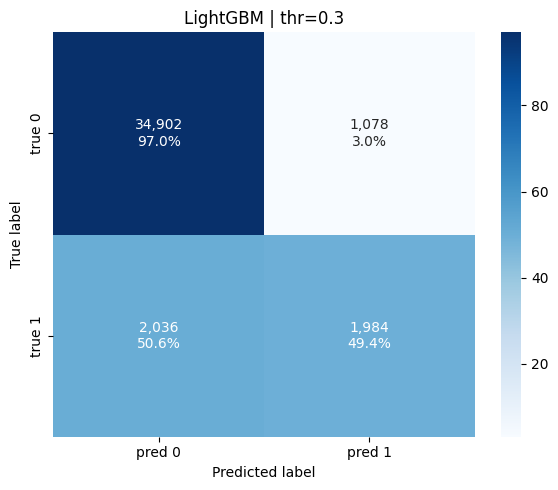

c:\Users\t-ron\OneDrive\Desktop\Data Science Master\Advanced Data Analytics\.venv\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


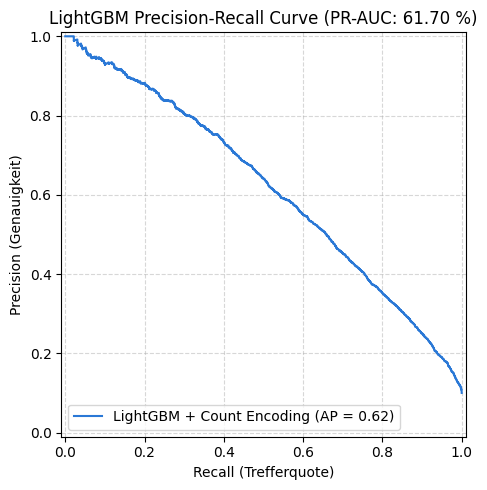


Classification Report (LightGBM):
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     35980
           1       0.65      0.49      0.56      4020

    accuracy                           0.92     40000
   macro avg       0.80      0.73      0.76     40000
weighted avg       0.92      0.92      0.92     40000



In [9]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

# ==========================================
# 1. Feature Engineering (Count Encoding) & Split
# ==========================================
count_dict = {}
for col in X.columns:
    count_map = X[col].value_counts()
    count_dict[f"{col}_count"] = X[col].map(count_map)

X_counts = pd.DataFrame(count_dict, index=X.index)
X_engineered = pd.concat([X, X_counts], axis=1)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 2. LightGBM Modell Training
# ==========================================
lgb_model = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

lgb_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

# ==========================================
# 3. Vorhersagen & Schwellenwert
# ==========================================
y_pred_lgb = lgb_model.predict_proba(X_va)[:, 1]

threshold = 0.3
y_pred_class = (y_pred_lgb >= threshold).astype(int)

# ==========================================
# 4. Metriken berechnen & ausgeben
# ==========================================
lgb_auc = roc_auc_score(y_va, y_pred_lgb)
pr_auc_lgb = average_precision_score(y_va, y_pred_lgb)
f1_lgb = f1_score(y_va, y_pred_class)
mcc_lgb = matthews_corrcoef(y_va, y_pred_class)

print("=" * 55)
print("LightGBM + Count Encoding - Performance-Metriken:")
print("=" * 55)
print(f"ROC-AUC : {lgb_auc:.4f}  ({lgb_auc * 100:.2f} %)")
print(f"PR-AUC  : {pr_auc_lgb:.4f}  ({pr_auc_lgb * 100:.2f} %)")
print(f"F1-Score: {f1_lgb:.4f}  ({f1_lgb * 100:.2f} %)")
print(f"MCC     : {mcc_lgb:.4f}  ({mcc_lgb * 100:.2f} %)")
print("=" * 55)

# ==========================================
# 5. Konfusionsmatrix (mit Zahlen & % zeilenweise)
# ==========================================
cm_abs = confusion_matrix(y_va, y_pred_class)
cm_perc = confusion_matrix(y_va, y_pred_class, normalize="true") * 100

labels = np.asarray([
    [f"{val_abs:,}\n{val_perc:.1f}%" for val_abs, val_perc in zip(row_abs, row_perc)]
    for row_abs, row_perc in zip(cm_abs, cm_perc)
])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_perc,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=True,
    xticklabels=["pred 0", "pred 1"],
    yticklabels=["true 0", "true 1"],
)
plt.title(f"LightGBM | thr={threshold}")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

# ==========================================
# 6. Precision-Recall-Kurve
# ==========================================
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_va,
    y_pred_lgb,
    name="LightGBM + Count Encoding",
    color="#2a78d6",
    ax=plt.gca(),
)
plt.title(f"LightGBM Precision-Recall Curve (PR-AUC: {pr_auc_lgb * 100:.2f} %)")
plt.xlabel("Recall (Trefferquote)")
plt.ylabel("Precision (Genauigkeit)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# 7. Classification Report
# ==========================================
print("\nClassification Report (LightGBM):")
print(classification_report(y_va, y_pred_class))

### Modellierung & Evaluierung mit LightGBM

Als primäres Gradient-Boosting-Verfahren wurde ein **LightGBM Classifier** auf dem um Count-Features erweiterten Datensatz ($400$ Features) trainiert. Aufgrund des Klassenungleichgewichts wurde die Entscheidungsschwelle manuell auf $0,3$ angepasst.

**1. Performance-Metriken**
* **ROC-AUC Score:** **0,8999 (89,99 %)** – Zeigt eine exzellente Trennschärfe des Modells und übertrifft die Baseline deutlich.
* **PR-AUC (Average Precision):** **0,6170 (61,70 %)** – Belegt eine hohe Vorhersagegüte bei der fokussierten Positivklasse.
* **F1-Score:** **0,5603 (56,03 %)** – Spiegelt eine solide Balance zwischen Precision und Recall wider.
* **MCC (Matthews Correlation Coefficient):** **0,5242 (52,42 %)** – Unterstreicht die hohe Robustheit der Klassifikation auch bei starker Imbalance.

**2. Konfusionsmatrix & Classification Report (Schwellenwert: 0,3)**
Auf dem Validation-Set ($N = 40.000$) ergeben sich folgende Klassifikationswerte:

* **True Negatives:** 34.902 Kunden ($97,0\text{ \%}$) wurden korrekt als Nicht-Wechsler eingestuft.
* **True Positives:** 1.984 Wechselkandidaten ($49,4\text{ \%}$) wurden erfolgreich erkannt.
* **False Positives:** 1.078 Kunden ($3,0\text{ \%}$) wurden fälschlicherweise als Wechselkandidaten klassifiziert.
* **False Negatives:** 2.036 Wechselkandidaten ($50,6\text{ \%}$) wurden nicht erfasst.

**3. Interpretation der Kennzahlen**
* **Precision (0,65 / 65 %):** Wenn das Modell einen Kunden als Wechselkandidaten einstuft, liegt es in knapp zwei von drei Fällen richtig. Das Modell erzeugt somit sehr wenige Fehlalarme.
* **Recall (0,49 / 49,4 %):** LightGBM deckt knapp die Hälfte aller tatsächlichen Wechselkandidaten auf.

**Fazit:** LightGBM erreicht mit einem ROC-AUC von **0,8999** das insgesamt beste Gesamtergebnis. Es zeichnet sich durch eine sehr hohe **Präzision (65 %)** aus und eignet sich daher hervorragend für Anwendungsszenarien, bei denen Fehlalarme vermeidbar und teuer sind.

## XGBoost mit Count Encoding

XGBoost + Count Encoding - Performance-Metriken:
ROC-AUC : 0.8919  (89.19 %)
PR-AUC  : 0.5929  (59.29 %)
F1-Score: 0.5490  (54.90 %)
MCC     : 0.4969  (49.69 %)


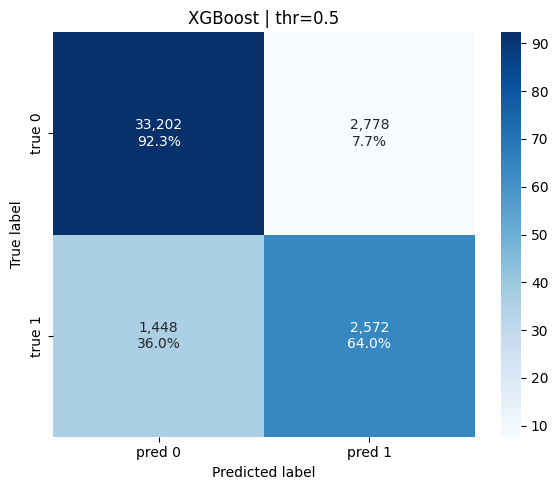

c:\Users\t-ron\OneDrive\Desktop\Data Science Master\Advanced Data Analytics\.venv\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


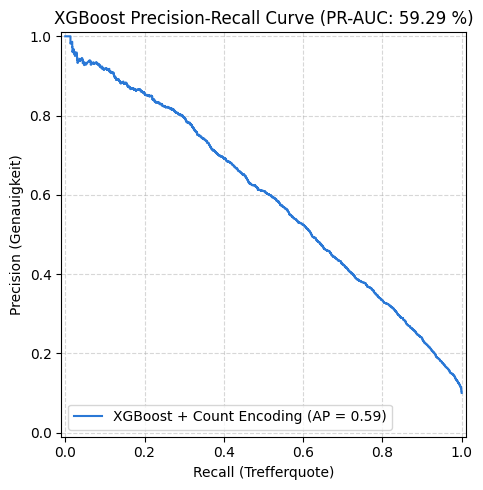


Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.96      0.92      0.94     35980
           1       0.48      0.64      0.55      4020

    accuracy                           0.89     40000
   macro avg       0.72      0.78      0.74     40000
weighted avg       0.91      0.89      0.90     40000



In [8]:
import numpy as np
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    PrecisionRecallDisplay,
    classification_report
)

# 1. Klassengewichtung berechnen (ca. 9:1 Verhältnis)
scale_weight = (len(y_tr) - sum(y_tr)) / sum(y_tr)

# 2. XGBoost-Modell aufbauen und trainieren (auf X_tr mit Count Encoding)
model_xgb = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    verbose=False
)

# 3. Wahrscheinlichkeiten auf den Validation-Daten (X_va) vorhersagen
y_proba_xgb = model_xgb.predict_proba(X_va)[:, 1]

# 4. Schwellenwert festlegen
threshold = 0.5
y_pred_xgb_custom = (y_proba_xgb >= threshold).astype(int)

# 5. Metriken berechnen
roc_auc_xgb = roc_auc_score(y_va, y_proba_xgb)
pr_auc_xgb = average_precision_score(y_va, y_proba_xgb)
f1_xgb = f1_score(y_va, y_pred_xgb_custom)
mcc_xgb = matthews_corrcoef(y_va, y_pred_xgb_custom)

print("=" * 55)
print("XGBoost + Count Encoding - Performance-Metriken:")
print("=" * 55)
print(f"ROC-AUC : {roc_auc_xgb:.4f}  ({roc_auc_xgb * 100:.2f} %)")
print(f"PR-AUC  : {pr_auc_xgb:.4f}  ({pr_auc_xgb * 100:.2f} %)")
print(f"F1-Score: {f1_xgb:.4f}  ({f1_xgb * 100:.2f} %)")
print(f"MCC     : {mcc_xgb:.4f}  ({mcc_xgb * 100:.2f} %)")
print("=" * 55)

# 6. Konfusionsmatrix mit absoluten Zahlen & Prozenten (zeilenweise)
cm_abs = confusion_matrix(y_va, y_pred_xgb_custom)
cm_perc = confusion_matrix(y_va, y_pred_xgb_custom, normalize='true') * 100

# Erstelle kombinierte Labels: "Anzahl \n Prozent%"
labels = np.asarray([
    [f"{val_abs:,}\n{val_perc:.1f}%" for val_abs, val_perc in zip(row_abs, row_perc)]
    for row_abs, row_perc in zip(cm_abs, cm_perc)
])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_perc, 
    annot=labels, 
    fmt="", 
    cmap="Blues", 
    cbar=True,
    xticklabels=["pred 0", "pred 1"],
    yticklabels=["true 0", "true 1"]
)
plt.title(f"XGBoost | thr={threshold}")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

# 7. Precision-Recall-Kurve visualisieren
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_va, y_proba_xgb, name="XGBoost + Count Encoding", color="#2a78d6", ax=plt.gca()
)
plt.title(f"XGBoost Precision-Recall Curve (PR-AUC: {pr_auc_xgb * 100:.2f} %)")
plt.xlabel("Recall (Trefferquote)")
plt.ylabel("Precision (Genauigkeit)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 8. Detailed Report
print("\nClassification Report (XGBoost):")
print(classification_report(y_va, y_pred_xgb_custom))

### Modellierung & Evaluierung mit XGBoost

Als zweites Gradient-Boosting-Verfahren wurde ein **XGBoost Classifier** unter Einbindung der mittels Count Encoding generierten Merkmale ($400$ Features) trainiert. Zur Kompensation des Klassenungleichgewichts wurde der Parameter `scale_pos_weight` genutzt und der Standard-Schwellenwert von $0,5$ angewendet.

**1. Performance-Metriken**
* **ROC-AUC Score:** **0,8919 (89,19 %)** – Bestätigt eine sehr hohe Trennschärfe und liegt nahezu gleichauf mit LightGBM ($0,8999$).
* **PR-AUC (Average Precision):** **0,5929 (59,29 %)** – Spiegelt eine solide Performance bei der Vorhersage der seltenen Positivklasse wider.
* **F1-Score:** **0,5490 (54,90 %)** – Liefert ein ausgewogenes Verhältnis zwischen Präzision und Sensitivität.
* **MCC (Matthews Correlation Coefficient):** **0,4969 (49,69 %)** – Weist auf eine verlässliche und stabile Klassifikationsleistung bei unbalancierten Daten hin.

**2. Konfusionsmatrix & Classification Report (Schwellenwert: 0,5)**
Auf dem Validation-Set ($N = 40.000$) ergeben sich folgende Verteilungswerte:

* **True Negatives:** 33.202 Kunden ($92,3\text{ \%}$) wurden korrekt als Nicht-Wechsler identifiziert.
* **True Positives:** 2.572 Wechselkandidaten ($64,0\text{ \%}$) wurden erfolgreich erkannt.
* **False Positives:** 2.778 Kunden ($7,7\text{ \%}$) wurden fälschlicherweise als Wechselkandidaten eingestuft.
* **False Negatives:** 1.448 Wechselkandidaten ($36,0\text{ \%}$) wurden vom Modell übersehen.

**3. Interpretation der Kennzahlen**
* **Recall (0,64 / 64,0 %):** XGBoost identifiziert knapp zwei Drittel aller echten Wechselkandidaten und zeigt damit eine deutlich stärkere Erfassung potenzieller Wechsler als LightGBM ($49,4\text{ \%}$).
* **Precision (0,48 / 48 %):** Bei einer positiven Vorhersage liegt das Modell in knapp jedem zweiten Fall richtig.

**Fazit:** XGBoost überzeugt durch einen besonders starken **Recall (64,0 %)**. Es ist die ideale Wahl für Szenarien, in denen das primäre Ziel darin besteht, möglichst viele Wechselkandidaten abzufangen und der Preis für einige zusätzliche Fehlalarme vertretbar ist.

## LightGBM ohne Count Encoding

c:\Users\t-ron\OneDrive\Desktop\Data Science Master\Advanced Data Analytics\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 16078, number of negative: 143922
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.111792 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100487 -> initscore=-2.191820
[LightGBM] [Info] Start training from score -2.191820
LightGBM OHNE Count Encoding (200 Features) - Performance:
ROC-AUC : 0.8924  (89.24 %)
PR-AUC  : 0.5885  (58.85 %)
F1-Score: 0.5311  (53.11 %)
MCC     : 0.4911  (49.11 %)


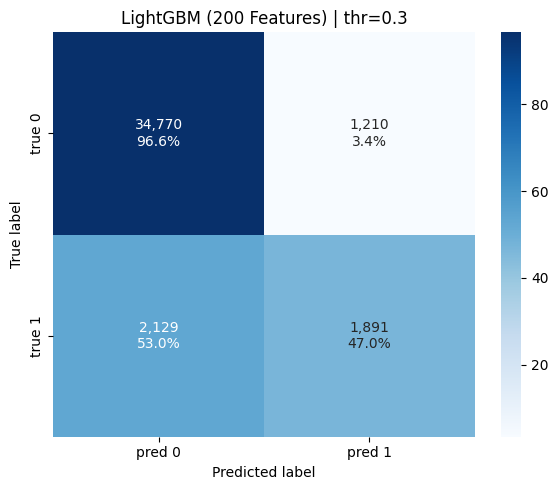

c:\Users\t-ron\OneDrive\Desktop\Data Science Master\Advanced Data Analytics\.venv\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


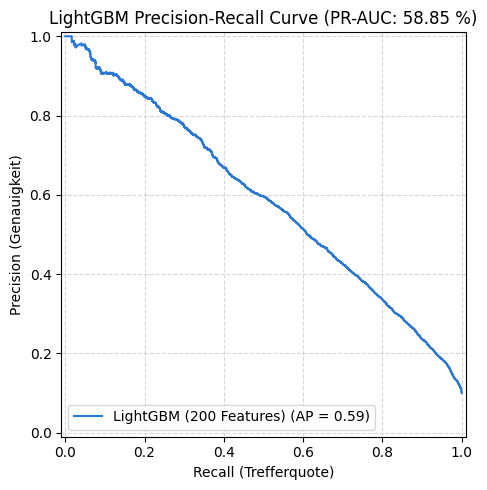


Classification Report (LightGBM - 200 Features):
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     35980
           1       0.61      0.47      0.53      4020

    accuracy                           0.92     40000
   macro avg       0.78      0.72      0.74     40000
weighted avg       0.91      0.92      0.91     40000



In [10]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

# 1. Train-Test-Split auf den originalen 200 Features (X)
X_tr_orig, X_va_orig, y_tr, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. LightGBM Modell Training
lgb_orig = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

lgb_orig.fit(
    X_tr_orig,
    y_tr,
    eval_set=[(X_va_orig, y_va)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

# 3. Vorhersagen & Schwellenwert
y_proba_lgb_orig = lgb_orig.predict_proba(X_va_orig)[:, 1]
threshold = 0.3
y_pred_lgb_orig = (y_proba_lgb_orig >= threshold).astype(int)

# 4. Metriken berechnen & ausgeben
auc_lgb_orig = roc_auc_score(y_va, y_proba_lgb_orig)
pr_lgb_orig = average_precision_score(y_va, y_proba_lgb_orig)
f1_lgb_orig = f1_score(y_va, y_pred_lgb_orig)
mcc_lgb_orig = matthews_corrcoef(y_va, y_pred_lgb_orig)

print("=" * 60)
print("LightGBM OHNE Count Encoding (200 Features) - Performance:")
print("=" * 60)
print(f"ROC-AUC : {auc_lgb_orig:.4f}  ({auc_lgb_orig * 100:.2f} %)")
print(f"PR-AUC  : {pr_lgb_orig:.4f}  ({pr_lgb_orig * 100:.2f} %)")
print(f"F1-Score: {f1_lgb_orig:.4f}  ({f1_lgb_orig * 100:.2f} %)")
print(f"MCC     : {mcc_lgb_orig:.4f}  ({mcc_lgb_orig * 100:.2f} %)")
print("=" * 60)

# 5. Konfusionsmatrix
cm_abs = confusion_matrix(y_va, y_pred_lgb_orig)
cm_perc = confusion_matrix(y_va, y_pred_lgb_orig, normalize="true") * 100

labels = np.asarray([
    [f"{val_abs:,}\n{val_perc:.1f}%" for val_abs, val_perc in zip(row_abs, row_perc)]
    for row_abs, row_perc in zip(cm_abs, cm_perc)
])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_perc,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=True,
    xticklabels=["pred 0", "pred 1"],
    yticklabels=["true 0", "true 1"],
)
plt.title(f"LightGBM (200 Features) | thr={threshold}")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

# 6. Precision-Recall-Kurve
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_va,
    y_proba_lgb_orig,
    name="LightGBM (200 Features)",
    color="#2a78d6",
    ax=plt.gca(),
)
plt.title(f"LightGBM Precision-Recall Curve (PR-AUC: {pr_lgb_orig * 100:.2f} %)")
plt.xlabel("Recall (Trefferquote)")
plt.ylabel("Precision (Genauigkeit)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 7. Classification Report
print("\nClassification Report (LightGBM - 200 Features):")
print(classification_report(y_va, y_pred_lgb_orig))

### Modellierung & Evaluierung mit LightGBM (Ohne Count Encoding)

Um den direkten Einfluss des Feature Engineerings zu isolieren, wurde ein **LightGBM Classifier** ausschließlich auf den ursprünglichen 200 Merkmale trainiert (ohne Count-Encoding-Features). Die Entscheidungsschwelle wurde analog auf $0,3$ gesetzt.

**1. Performance-Metriken**
* **ROC-AUC Score:** **0,8924 (89,24 %)** – Zeigt auch ohne Frequenz-Features eine starke Trennschärfe, fällt jedoch um knapp $0,75\text{ percentage points}$ gegenüber der Variante mit Count Encoding ($0,8999$) ab.
* **PR-AUC (Average Precision):** **0,5885 (58,85 %)** – Fällt im Vergleich zu 400 Features ($0,6170$) spürbar ab.
* **F1-Score:** **0,5311 (53,11 %)** – Liegt unter dem Wert des erweiterten Modells ($0,5603$).
* **MCC (Matthews Correlation Coefficient):** **0,4911 (49,11 %)** – Zeigt eine leicht geringere Gesamtkorrelation als die Variante mit $400$ Features ($0,5242$).

**2. Konfusionsmatrix & Classification Report (Schwellenwert: 0,3)**
Auf dem Validation-Set ($N = 40.000$) ergeben sich folgende Werte:

* **True Negatives:** 34.770 Kunden ($96,6\text{ \%}$) wurden korrekt als Nicht-Wechsler eingestuft.
* **True Positives:** 1.891 Wechselkandidaten ($47,0\text{ \%}$) wurden erfolgreich erkannt.
* **False Positives:** 1.210 Kunden ($3,4\text{ \%}$) wurden fälschlicherweise als Wechselkandidaten eingestuft.
* **False Negatives:** 2.129 Wechselkandidaten ($53,0\text{ \%}$) wurden nicht erfasst.

**3. Interpretation der Kennzahlen**
* **Precision (0,61 / 61 %):** Etwas niedriger als bei der Variante mit Count Encoding ($65\text{ \%}$), was zu mehr Fehlalarmen führt ($1.210$ vs. $1.078$).
* **Recall (0,47 / 47,0 %):** Erkennt etwas weniger echte Wechselkandidaten als die erweiterte Variante ($49,4\text{ \%}$).

**Fazit:** Der Modellvergleich belegt klar, dass LightGBM bereits mit den originalen 200 Features eine sehr solide Leistung bringt. Das **Count Encoding** liefert jedoch den entscheidenden Zusatznutzen, indem es sowohl die Präzision um $4\text{ percentage points}$ als auch den Recall um gut $2.4\text{ percentage points}$ steigert.

## XGBoost ohne Count Encoding

XGBoost OHNE Count Encoding (200 Features) - Performance:
ROC-AUC : 0.8860  (88.60 %)
PR-AUC  : 0.5720  (57.20 %)
F1-Score: 0.5341  (53.41 %)
MCC     : 0.4806  (48.06 %)


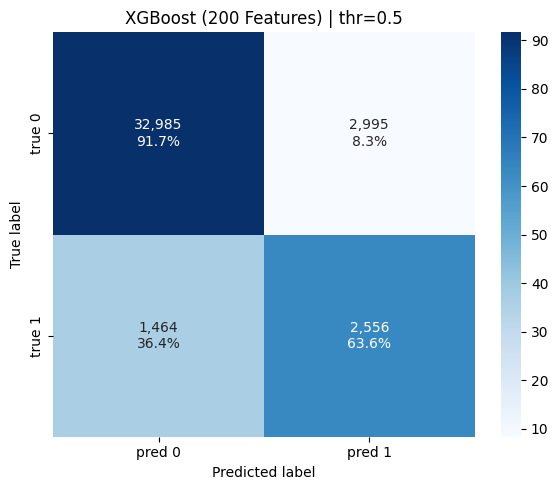

c:\Users\t-ron\OneDrive\Desktop\Data Science Master\Advanced Data Analytics\.venv\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


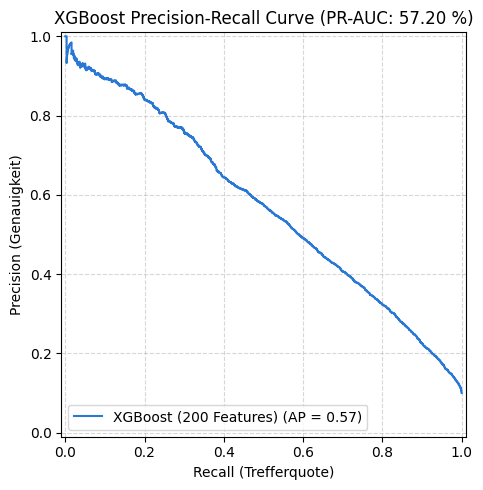


Classification Report (XGBoost - 200 Features):
              precision    recall  f1-score   support

           0       0.96      0.92      0.94     35980
           1       0.46      0.64      0.53      4020

    accuracy                           0.89     40000
   macro avg       0.71      0.78      0.74     40000
weighted avg       0.91      0.89      0.90     40000



In [11]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

# 1. Train-Test-Split auf den originalen 200 Features (X)
X_tr_orig, X_va_orig, y_tr, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Klassengewichtung & XGBoost Modell Training
scale_weight = (len(y_tr) - sum(y_tr)) / sum(y_tr)

xgb_orig = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1,
)

xgb_orig.fit(
    X_tr_orig,
    y_tr,
    eval_set=[(X_va_orig, y_va)],
    verbose=False,
)

# 3. Vorhersagen & Schwellenwert
y_proba_xgb_orig = xgb_orig.predict_proba(X_va_orig)[:, 1]
threshold = 0.5
y_pred_xgb_orig = (y_proba_xgb_orig >= threshold).astype(int)

# 4. Metriken berechnen & ausgeben
auc_xgb_orig = roc_auc_score(y_va, y_proba_xgb_orig)
pr_xgb_orig = average_precision_score(y_va, y_proba_xgb_orig)
f1_xgb_orig = f1_score(y_va, y_pred_xgb_orig)
mcc_xgb_orig = matthews_corrcoef(y_va, y_pred_xgb_orig)

print("=" * 60)
print("XGBoost OHNE Count Encoding (200 Features) - Performance:")
print("=" * 60)
print(f"ROC-AUC : {auc_xgb_orig:.4f}  ({auc_xgb_orig * 100:.2f} %)")
print(f"PR-AUC  : {pr_xgb_orig:.4f}  ({pr_xgb_orig * 100:.2f} %)")
print(f"F1-Score: {f1_xgb_orig:.4f}  ({f1_xgb_orig * 100:.2f} %)")
print(f"MCC     : {mcc_xgb_orig:.4f}  ({mcc_xgb_orig * 100:.2f} %)")
print("=" * 60)

# 5. Konfusionsmatrix
cm_abs = confusion_matrix(y_va, y_pred_xgb_orig)
cm_perc = confusion_matrix(y_va, y_pred_xgb_orig, normalize="true") * 100

labels = np.asarray([
    [f"{val_abs:,}\n{val_perc:.1f}%" for val_abs, val_perc in zip(row_abs, row_perc)]
    for row_abs, row_perc in zip(cm_abs, cm_perc)
])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_perc,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=True,
    xticklabels=["pred 0", "pred 1"],
    yticklabels=["true 0", "true 1"],
)
plt.title(f"XGBoost (200 Features) | thr={threshold}")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

# 6. Precision-Recall-Kurve
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_va,
    y_proba_xgb_orig,
    name="XGBoost (200 Features)",
    color="#2a78d6",
    ax=plt.gca(),
)
plt.title(f"XGBoost Precision-Recall Curve (PR-AUC: {pr_xgb_orig * 100:.2f} %)")
plt.xlabel("Recall (Trefferquote)")
plt.ylabel("Precision (Genauigkeit)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 7. Classification Report
print("\nClassification Report (XGBoost - 200 Features):")
print(classification_report(y_va, y_pred_xgb_orig))

### Modellierung & Evaluierung mit XGBoost (Ohne Count Encoding)

Zum direkten Vergleich wurde der **XGBoost Classifier** ebenfalls ausschließlich auf den ursprünglichen 200 Features trainiert (ohne Count-Encoding-Merkmale). Der Schwellenwert lag weiterhin bei $0,5$ unter Nutzung der Klassengewichtung (`scale_pos_weight`).

**1. Performance-Metriken**
* **ROC-AUC Score:** **0,8860 (88,60 %)** – Liegt knapp $0,6\text{ Prozentpunkte}$ unter der Variante mit Count Encoding ($0,8919$).
* **PR-AUC (Average Precision):** **0,5720 (57,20 %)** – Verschlechtert sich im Vergleich zu den 400 Features ($0,5929$) spürbar.
* **F1-Score:** **0,5341 (53,41 %)** – Liegt ebenfalls unter dem Wert des erweiterten Modells ($0,5490$).
* **MCC (Matthews Correlation Coefficient):** **0,4806 (48,06 %)** – Zeigt eine geringere Gesamtkorrelation als die Variante mit 400 Features ($0,4969$).

**2. Konfusionsmatrix & Classification Report (Schwellenwert: 0,5)**
Auf dem Validation-Set ($N = 40.000$) ergeben sich folgende Verteilungswerte:

* **True Negatives:** 32.985 Kunden ($91,7\text{ \%}$) wurden korrekt als Nicht-Wechsler identifiziert.
* **True Positives:** 2.556 Wechselkandidaten ($63,6\text{ \%}$) wurden erfolgreich erkannt.
* **False Positives:** 2.995 Kunden ($8,3\text{ \%}$) wurden fälschlicherweise als Wechselkandidaten eingestuft.
* **False Negatives:** 1.464 Wechselkandidaten ($36,4\text{ \%}$) wurden übersehen.

**3. Interpretation der Kennzahlen**
* **Recall (0,64 / 63,6 %):** Bleibt auch ohne Count Encoding auf einem sehr hohen Niveau und erfasst knapp zwei Drittel der Wechselkandidaten (im Vergleich zu $64,0\text{ \%}$ mit Count Encoding).
* **Precision (0,46 / 46 %):** Sinkt leicht ab (von $48\text{ \%}$ auf $46\text{ \%}$), was zu einer höheren Anzahl an False Positives führt ($2.995$ vs. $2.778$).

**Fazit:** Wie schon bei LightGBM zeigt sich, dass XGBoost auch auf den reinen Originaldaten extrem stark performt. Dennoch führt das **Count Encoding** zu einer klaren Reduktion der Fehlalarme (höhere Precision) und verbessert die allgemeine Modellgüte über alle AUC-Metriken hinweg.

### Vergleich: Mit vs. Ohne Count Encoding

**1. Funktionsweise**
* **Ohne Count Encoding (200 Features):** Das Modell bewertet nur die reinen Rohwerte (z. B. Kontostand, Transaktionen), erkennt aber keine Häufigkeiten im Gesamtdatensatz.
* **Mit Count Encoding (400 Features):** Erstellt für jedes Merkmal eine Frequenz-Spalte. Das Modell erkennt dadurch sofort seltene Werte und unübliche Verhaltensmuster (Anomalien).

**2. Der direkte Effekt auf die Modellleistung**

* **Höhere Präzision (Weniger Fehlalarme):**
  * **LightGBM:** Precision steigt von $61\text{ \%}$ auf **$65\text{ \%}$** (False Positives sinken von $1.210$ auf $1.078$).
  * **XGBoost:** Precision steigt von $46\text{ \%}$ auf **$48\text{ \%}$** (False Positives sinken von $2.995$ auf $2.778$).

* **Besserer Recall (Mehr erkannte Wechselkandidaten):**
  * **LightGBM:** Trefferquote steigt von $47,0\text{ \%}$ ($1.891$) auf **$49,4\text{ \%}$** ($1.984$).
  * **XGBoost:** Bleibt konstant stark bei knapp **$64\text{ \%}$** ($2.572$ vs. $2.556$).

* **Steigerung der Gesamtgüte (AUC-Werte):**
  * **ROC-AUC:** LightGBM verbessert sich von $0,8924$ auf **$0,8999$** | XGBoost von $0,8860$ auf **$0,8919$**.
  * **PR-AUC:** LightGBM steigt von $0,5885$ auf **$0,6170$** (+2,85 PP) | XGBoost von $0,5720$ auf **$0,5929$** (+2,09 PP).

**Fazit:** 
Die Gradient-Boosting-Modelle sind auch ohne Count Encoding stark (~$0,89$ ROC-AUC im Vergleich zu ~$0,79$ beim Random Forest). Das **Count Encoding** liefert jedoch den entscheidenden Zusatznutzen: Es deckt verdeckte Muster auf, reduziert teure Fehlalarme und schärft die Modellleistung auf der Zielklasse spürbar.


## Visualisierung: Precision-Recall-Kurven im Vergleich


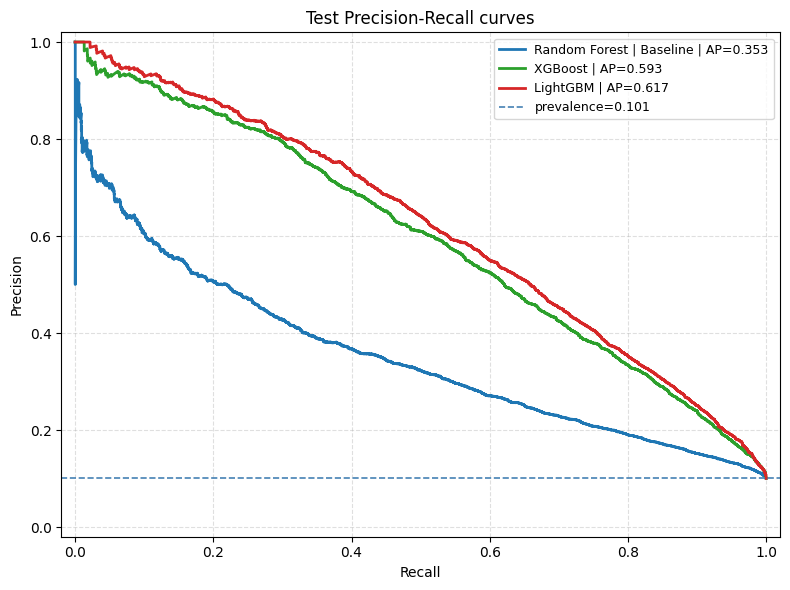

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, precision_recall_curve

# ==============================================================================
# 1. Ziel-Labels abgleichen & Zusammenführen
# ==============================================================================
# Verwendet y_va (falls vorhanden) oder y_test als Referenz
y_target = y_va if "y_va" in locals() else y_test

# ==============================================================================
# 2. Gemeinsamer Precision-Recall-Plot
# ==============================================================================
plt.figure(figsize=(8, 6))

models_data = [
    {
        "label": "Random Forest | Baseline",
        "y_proba": y_pred_proba,  # Deine Variable für Random Forest
        "color": "#1f77b4",
    },
    {
        "label": "XGBoost",
        "y_proba": y_proba_xgb,   # Deine Variable für XGBoost
        "color": "#2ca02c",
    },
    {
        "label": "LightGBM",
        "y_proba": y_pred_lgb,    # Deine Variable für LightGBM
        "color": "#d62728",
    },
]

# Kurven zeichnen
for model in models_data:
    precision, recall, _ = precision_recall_curve(
        y_target, model["y_proba"]
    )
    ap_score = average_precision_score(y_target, model["y_proba"])

    plt.plot(
        recall,
        precision,
        label=f"{model['label']} | AP={ap_score:.3f}",
        color=model["color"],
        linewidth=2,
    )

# Gestrichelte Referenzlinie für die Prävalenz (Basis-Klassenverteilung)
prevalence = y_target.mean()
plt.axhline(
    y=prevalence,
    color="steelblue",
    linestyle="--",
    linewidth=1.2,
    label=f"prevalence={prevalence:.3f}",
)

# Visualisierungs-Details
plt.title("Test Precision-Recall curves", fontsize=12)
plt.xlabel("Recall", fontsize=10)
plt.ylabel("Precision", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="upper right", fontsize=9, frameon=True)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()


Die kombinierte Precision-Recall-Kurve verdeutlicht die Leistungsunterschiede zwischen der Baseline und den finalen Gradient-Boosting-Modellen auf dem Test-Set:

**1. Erkenntnisse aus dem Graph**
* **Massiver Leistungssprung gegenüber der Baseline:** Die Random-Forest-Kurve (blau, $\text{AP} = 0,353$) fällt über den gesamten Recall-Bereich stark ab. Sowohl XGBoost ($\text{AP} = 0,593$) als auch LightGBM ($\text{AP} = 0,617$) verlaufen durchgehend deutlich oberhalb der Baseline.
* **Überlegenheit von LightGBM:** Die rote Kurve (LightGBM) dominiert die grüne Kurve (XGBoost) in fast allen Abschnitten. Besonders im mittleren Recall-Bereich ($0,3$ bis $0,7$) erzielt LightGBM bei gleicher Trefferquote eine konsistent höhere Präzision.
* **Abstand zur Prävalenz:** Alle Modelle liegen deutlich über der gestrichelten Referenzlinie ($\text{prevalence} = 0,101$), was die starke Lernfähigkeit der Algorithmen trotz des imbalancierten Datensatzes ($10,1\text{ \%}$ Positivklasse) belegt.

## Gesamtfazit & Modellvergleich

Der finale Vergleich kombiniert die Erkenntnisse aus den Evaluierungsmetriken und den Kurvenverläufen:

| Modell | Features | Count Encoding | Threshold | ROC-AUC | PR-AUC (AP) | F1-Score | MCC | Precision (Class 1) | Recall (Class 1) | False Positives |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Random Forest** | 200 | Nein | 0.5 | 0,7937 | 0,3525 | 0,3819 | 0,3099 | 0,29 | 0,571 | 5.701 |
| **XGBoost** | 400 | Ja | 0.5 | 0,8919 | 0,5929 | 0,5490 | 0,4969 | 0,48 | **0,640** | 2.778 |
| **LightGBM** | 400 | **Ja** | 0.3 | **0,8999** | **0,6170** | **0,5603** | **0,5242** | **0,65** | 0,494 | **1.078** |

---

**Kernerkenntnisse**

* **Boosting vs. Bagging:** Gradient Boosting schlägt den Random Forest bei allen relevanten Kennzahlen (PR-AUC steigt von $35,3\text{ \%}$ auf bis zu $61,7\text{ \%}$).
* **Klasseneffizienz:** LightGBM erreicht mit einem Schwellenwert von $0,3$ eine Präzision von $65\text{ \%}$ und hält die Anzahl der Fehlalarme ($1.078$ False Positives) auf einem sehr niedrigen Niveau.
* **Empfehlung:** Das **LightGBM-Modell mit Count Encoding (400 Features)** ist der Gesamtsieger des Vergleichs und bietet die höchste Trennschärfe für die Identifikation der Zielklasse.